In [1]:
import numpy as np
import scipy.stats as sps
import matplotlib.pyplot as plt

from surmise.emulation import emulator
from surmise.calibration import calibrator

# ----- SPECIFY MODEL'S PARAMETER SPACE
PARAMETER_ORDER = ["m", "b"]
M_IDX, B_IDX = (0, 1)
M_NAME = PARAMETER_ORDER[M_IDX]
B_NAME = PARAMETER_ORDER[B_IDX]
N_PARAMETERS = len(PARAMETER_ORDER)

# ----- SPECIFY CALIBRATOR
SAMPLER_METHOD     = {"bilby": "emcee"}
SAMPLER_ARGS       = {"parameter_order": PARAMETER_ORDER,
                     "clean": True}
# SAMPLER_METHOD     = "metropolis_hastings"
# SAMPLER_ARGS       = {"numsamp": 100000,
#                       "stepType": "normal",
#                       "stepParam": (0.15, 0.15),
#                       "verbose": True}
# SAMPLER_METHOD     = "LMC"
# SAMPLER_ARGS       = {"numsamp": 100000,
#                       "verbose": True}
#CALIBRATION_METHOD = "directbayes"
CALIBRATION_METHOD = "directbayeswoodbury"
CALIBRATION_ARGS   = {"sampler": SAMPLER_METHOD}
TOTAL_ARGS = {**CALIBRATION_ARGS, **SAMPLER_ARGS}

# ----- LINEAR MODEL
# True parameter values
THETA_STAR = {M_NAME: 3.3, B_NAME: -0.4}
THETA_STAR_ARR = np.array([THETA_STAR[p] for p in PARAMETER_ORDER]).reshape(1, N_PARAMETERS)

def model(x, theta):
    f = np.zeros((theta.shape[0], len(x)))
    for k in range(0, theta.shape[0]):
        m = theta[k, M_IDX]
        b = theta[k, B_IDX]
        f[k, :] = m * x + b
    return f.T

# ----- EXPERIMENTAL DATASET
N_DATA = 10
SIGMA = 0.50
X_MIN, X_MAX = (0.0, 5.0)
X_DATA = np.linspace(X_MIN, X_MAX, N_DATA)
f_star = model(X_DATA, THETA_STAR_ARR)
F_DATA = f_star + np.random.normal(0.0, SIGMA, f_star.shape)
SIGMA_DATA = SIGMA * np.ones(N_DATA)

# ----- STATISTICAL MODEL
class joint_prior:
    def lpdf(theta):
        m_values = sps.uniform.logpdf(theta[:, M_IDX],  2.2, 2.2)
        b_values = sps.uniform.logpdf(theta[:, B_IDX], -3.3, 8.8)
        return (m_values + b_values).reshape((theta.shape[0], 1))

    def rnd(n):
        m_samples = sps.uniform.rvs( 2.2, 2.2, size=n)
        b_samples = sps.uniform.rvs(-3.3, 8.8, size=n)
        return np.vstack((m_samples, b_samples)).T

# ----- ESTHETICS
plt.style.use("ggplot")
FONTSIZE      = 12
TICK_FONTSIZE = FONTSIZE - 2
MARKERSIZE    = 5
LINEWIDTH     = 2.0

17:12 bilby INFO    : Running for label 'label', output will be saved to 'outdir'
17:12 bilby INFO    : Analysis priors:
17:12 bilby INFO    : m=surmise._samplermethods.BilbyWrappers.BilbyJointPrior(dist=User-provided joint prior distribution, name='m', latex_label='m', unit=None)
17:12 bilby INFO    : b=surmise._samplermethods.BilbyWrappers.BilbyJointPrior(dist=User-provided joint prior distribution, name='b', latex_label='b', unit=None)
17:12 bilby INFO    : Analysis likelihood class: <class 'surmise._samplermethods.BilbyWrappers.BilbyLikelihood'>
17:12 bilby INFO    : Analysis likelihood noise evidence: nan
17:12 bilby INFO    : Single likelihood evaluation took 6.471e-05 s
17:12 bilby WARNING : Supplied argument 'use_grad' not an argument of 'Emcee', removing.
17:12 bilby INFO    : Using sampler Emcee with kwargs {'nwalkers': 500, 'a': 2, 'args': [], 'kwargs': {}, 'postargs': None, 'pool': None, 'live_dangerously': False, 'runtime_sortingfn': None, 'lnprob0': None, 'rstate0': None,


m^*              = 3.3
m posterior mean = 3.2795470833926053
m posterior std  = 0.14096705914071117
b^*              = -0.4
b posterior mean = -0.24907886948879443
b posterior std  = 0.41661301201865564


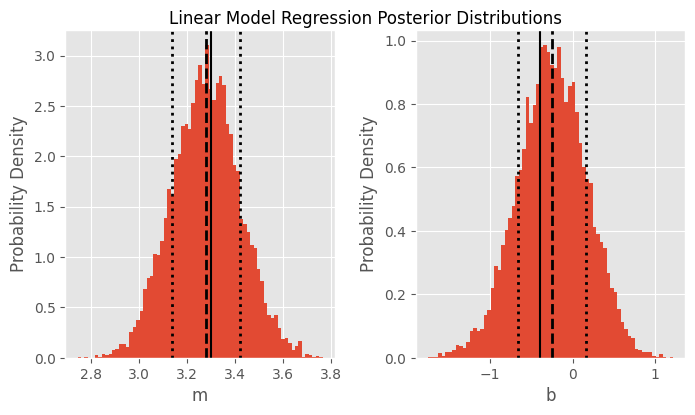

In [2]:
emu = emulator(passthroughfunc=model)
calibrator = calibrator(
    method=CALIBRATION_METHOD,
    emu=emu,
    x=X_DATA, y=F_DATA, yvar=SIGMA_DATA,
    thetaprior=joint_prior,
    args=TOTAL_ARGS
)

MC_theta_samples = calibrator.info["thetarnd"]

posterior_mean = calibrator.theta.mean()
m_posterior_mean = posterior_mean[M_IDX]
b_posterior_mean = posterior_mean[B_IDX]

posterior_std = np.sqrt(calibrator.theta.var())
m_posterior_std = posterior_std[M_IDX]
b_posterior_std = posterior_std[B_IDX]

print()
print(f"{M_NAME}^*              = {THETA_STAR[M_NAME]}")
print(f"{M_NAME} posterior mean = {m_posterior_mean}")
print(f"{M_NAME} posterior std  = {m_posterior_std}")
print(f"{B_NAME}^*              = {THETA_STAR[B_NAME]}")
print(f"{B_NAME} posterior mean = {b_posterior_mean}")
print(f"{B_NAME} posterior std  = {b_posterior_std}")

fig = plt.figure(1, figsize=(8, 4))
fig.suptitle("Linear Model Regression Posterior Distributions", fontsize=FONTSIZE)
fig.subplots_adjust(top=0.93, wspace=0.3)

subp = fig.add_subplot(121)
subp.hist(MC_theta_samples[:, M_IDX], bins='auto', density=True)
subp.axvline(THETA_STAR[M_NAME], color="black")
subp.axvline(m_posterior_mean, color="black",
             linestyle="--", linewidth=LINEWIDTH)
subp.axvline(m_posterior_mean - m_posterior_std, color="black",
             linestyle=":", linewidth=LINEWIDTH)
subp.axvline(m_posterior_mean + m_posterior_std, color="black",
             linestyle=":", linewidth=LINEWIDTH)
subp.set_xlabel(M_NAME, fontsize=FONTSIZE)
subp.set_ylabel("Probability Density", fontsize=FONTSIZE)
subp.grid(True)

subp = fig.add_subplot(122)
subp.hist(MC_theta_samples[:, B_IDX], bins='auto', density=True)
subp.axvline(THETA_STAR[B_NAME], color="black")
subp.axvline(b_posterior_mean, color="black",
             linestyle="--", linewidth=LINEWIDTH)
subp.axvline(b_posterior_mean - b_posterior_std, color="black",
             linestyle=":", linewidth=LINEWIDTH)
subp.axvline(b_posterior_mean + b_posterior_std, color="black",
             linestyle=":", linewidth=LINEWIDTH)
subp.set_xlabel(B_NAME, fontsize=FONTSIZE)
subp.set_ylabel("Probability Density", fontsize=FONTSIZE)
subp.grid(True)

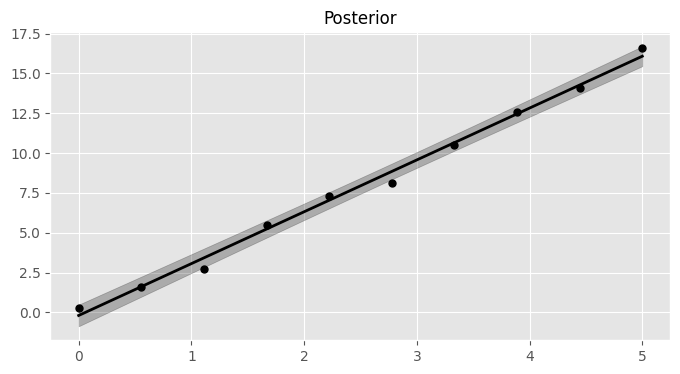

In [3]:
x_model = np.linspace(X_MIN, X_MAX, 100)

posterior_predict = emu(x_model, calibrator.theta.rnd(50))
posterior_predict_mean = np.mean(posterior_predict.mean(), axis=1)
posterior_predict_std = np.sqrt(np.std(posterior_predict.mean(), axis=1))

fig = plt.figure(2, figsize=(8, 4))
subp = fig.add_subplot(111)
subp.set_title("Posterior", fontsize=FONTSIZE)
subp.plot(X_DATA, F_DATA, 'ok', markersize=MARKERSIZE)
subp.plot(x_model, posterior_predict_mean, 'k-', linewidth=LINEWIDTH)
subp.fill_between(x_model,
                  posterior_predict_mean - posterior_predict_std,
                  posterior_predict_mean + posterior_predict_std,
                  color="black", alpha=0.25)
subp.grid(True)